# Lab2

1. STAR and SLURM
2. ResQC
3. RESM and Salmon

## STAR (Spliced Transcripts Alignment to a Reference) 
- In RNA-seq, reads come from non-contiguous locations in the genome (due to splicing) . An aligner must be aware of this.
- Fast as expense of being memory intensive
- Therefore, the computation needs to be done on server: If on school server you need to use SLURM

## RSeQC (W/ .BAM)
- mRNA is an unstable molecule. It is important to check if your sample has been degreaded before analysis
- REsQC is a python package 
  - tin.py
  - geneBody_coverage.py

## Salmon and RSEM(from FSATQ to count)
- Output of Salmon: ENSEMBLE ID of transcipt and you need to convert with BioMart for just one 
- RESM: start from .bam but slow 

# Lab 3

1. PAC and H-clustering
2. Batch Removal
3. DESeq2
4. KMeans
5. DAVID
6. GSEA

## PCA (主成分分析)

### 什么是PCA?

- 找到变量的最佳线性组合
- "最佳"意味着描述最大方差的变量
- 可以产生数据的低维摘要
    - 将每个样本的100个数字总结为2个数字
- 对可视化等非常有用

### PCA分析示例

我们将使用sklearn内置的数据集进行演示。

In [1]:
# Use rpy2 to load the R dataset 'decathlon2' from the 'factoextra' package
%load_ext rpy2.ipython


In [2]:

%%R
library(factoextra)
data(decathlon2)
head(decathlon2)


          X100m Long.jump Shot.put High.jump X400m X110m.hurdle Discus
SEBRLE    11.04      7.58    14.83      2.07 49.81        14.69  43.75
CLAY      10.76      7.40    14.26      1.86 49.37        14.05  50.72
BERNARD   11.02      7.23    14.25      1.92 48.93        14.99  40.87
YURKOV    11.34      7.09    15.19      2.10 50.42        15.31  46.26
ZSIVOCZKY 11.13      7.30    13.48      2.01 48.62        14.17  45.67
McMULLEN  10.83      7.31    13.76      2.13 49.91        14.38  44.41
          Pole.vault Javeline X1500m Rank Points Competition
SEBRLE          5.02    63.19  291.7    1   8217    Decastar
CLAY            4.92    60.15  301.5    2   8122    Decastar
BERNARD         5.32    62.77  280.1    4   8067    Decastar
YURKOV          4.72    63.44  276.4    5   8036    Decastar
ZSIVOCZKY       4.42    55.37  268.0    7   8004    Decastar
McMULLEN        4.42    56.37  285.1    8   7995    Decastar


Loading required package: ggplot2
Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa
In addition: Warning messages:
1: package ‘factoextra’ was built under R version 4.4.3 
2: package ‘ggplot2’ was built under R version 4.4.3 


In [3]:
import pandas as pd
%R -o decathlon2
print(type(decathlon2))
decathlon2.head()

<class 'pandas.core.frame.DataFrame'>


,X100m,Long.jump,Shot.put,High.jump,X400m,X110m.hurdle,Discus,Pole.vault,Javeline,X1500m,Rank,Points,Competition
SEBRLE,11.04,7.58,14.83,2.07,49.81,14.69,43.75,5.02,63.19,291.7,1,8217,Decastar
CLAY,10.76,7.40,14.26,1.86,49.37,14.05,50.72,4.92,60.15,301.5,2,8122,Decastar
BERNARD,11.02,7.23,14.25,1.92,48.93,14.99,40.87,5.32,62.77,280.1,4,8067,Decastar
YURKOV,11.34,7.09,15.19,2.10,50.42,15.31,46.26,4.72,63.44,276.4,5,8036,Decastar
ZSIVOCZKY,11.13,7.30,13.48,2.01,48.62,14.17,45.67,4.42,55.37,268.0,7,8004,Decastar


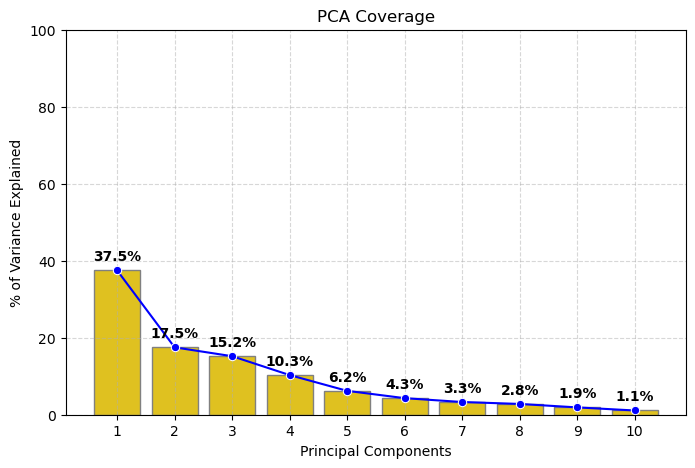

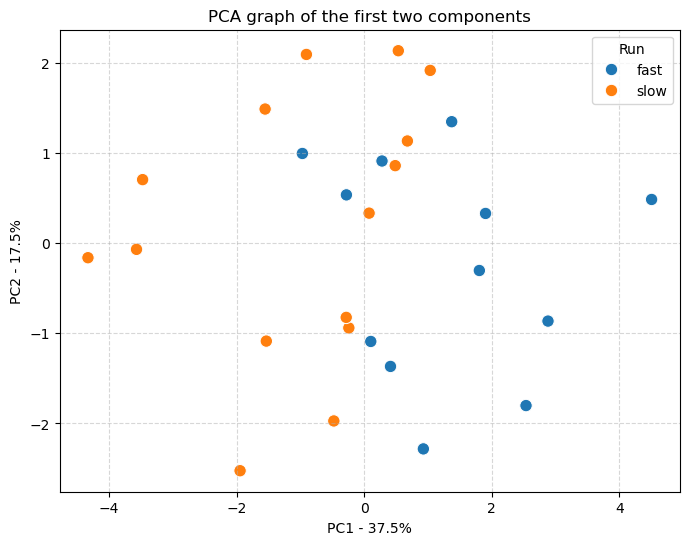

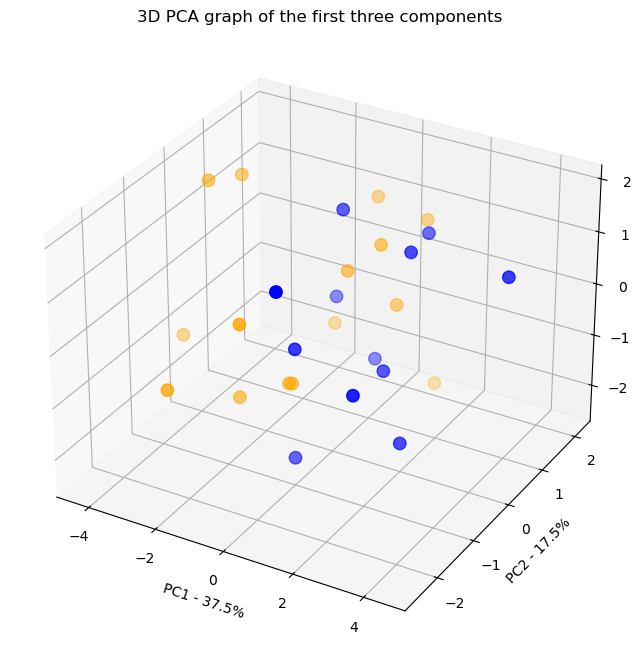

In [4]:
# %% [markdown]
# ## PCA
# - Finds the best linear combinations of the variables.
# - "Best" means the direction that describes the largest variance.
# - Can produce lower-dimensional summaries of the data.
# - Useful for visualization, among other things.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# %%
# ## PCA Analysis Example
# The decathlon dataset equivalent is available from seaborn or manually loaded
# We'll simulate it using the R version structure for demonstration.

# You can install datasets if needed: pip install pydataset
# Active individuals (1:23) and active variables (1:10)
decathlon2_active = decathlon2.iloc[:27, :10] # 前27行，前10列是有效数据
decathlon2_active.head()

# %%
# Perform PCA with scaling
scaler = StandardScaler() # Sklearn的scaler是计算z-score的
scaled_data = scaler.fit_transform(decathlon2_active)

pca = PCA()
pca_result = pca.fit_transform(scaled_data)

# Calculate explained variance ratio (%)
pca_var_per = np.round(pca.explained_variance_ratio_ * 100, 1) # 转换为百分比并四舍五入到一位小数

# %%
# Plot variance explained (equivalent to fviz_eig)
plt.figure(figsize=(8, 5))
sns.barplot(x=np.arange(1, len(pca_var_per)+1), y=pca_var_per, color="gold", edgecolor="gray")
sns.lineplot(x=np.arange(0, len(pca_var_per)), y=pca_var_per, marker="o", color="blue") # 清楚为什么这里的x要从0开始而上面从1开始，barplot是分类轴，lineplot是数值轴，无论bar的位置如何，lineplot都要从0开始

# for i, val in enumerate(pca_var_per):
#     plt.text(i, val + 1.0, f"{val}%", ha='center', va='bottom', 
#              fontsize=10, color='black', fontweight='bold')


for container in plt.gca().containers:
    # 使用 ax.bar_label() 自动添加标签是推荐的方法
    plt.bar_label(container, 
                 # 设置标签的格式，例如保留一位小数
                 fmt='%.1f%%', 
                 # 调整标签与条形顶部的间距
                 padding=5, 
                 fontsize=10, 
                 color='black', 
                 fontweight='bold',
                 label_type='edge')

plt.title("PCA Coverage")
plt.xlabel("Principal Components")
plt.ylabel("% of Variance Explained")
plt.ylim(0, 100)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# %%
# Prepare data for scatter plot (first two PCs)
pca_df = pd.DataFrame({
    'Sample': decathlon2_active.index,
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'X100m': decathlon2_active['X100m']
})

# Define color groups (fast/slow)
pca_df['Run'] = np.where(pca_df['X100m'] < 11, 'slow', 'fast') # where函数是条件选择函数，用于创建新列打标签

# %%
# Scatter plot of first two PCs
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Run', s=80)
plt.title("PCA graph of the first two components")
plt.xlabel(f"PC1 - {pca_var_per[0]}%")
plt.ylabel(f"PC2 - {pca_var_per[1]}%")
plt.legend(title="Run")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# 3D Scatter plot of first three PCs
from mpl_toolkits.mplot3d import Axes3D 
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2], 
                     c=np.where(pca_df['Run'] == 'fast', 'blue', 'orange'), s=80)
ax.set_title("3D PCA graph of the first three components")
ax.set_xlabel(f"PC1 - {pca_var_per[0]}%")
ax.set_ylabel(f"PC2 - {pca_var_per[1]}%")
ax.set_zlabel(f"PC3 - {pca_var_per[2]}%")
plt.show()

# %%
# ## Python Aside: PCA object
# In Python, PCA results are stored in an object (similar to R list).
# You can access individual elements like:
# - pca.components_ : loadings (eigenvectors)
# - pca.explained_variance_ : eigenvalues
# - pca.explained_variance_ratio_ : variance ratio
# - pca.mean_ : mean of features
# - pca.singular_values_ : singular values

## K-Means聚类

### 什么是K-Means?

- 一种无监督方法，用于对数据进行聚类（不提供标签/结果）
- 需要预先指定聚类数量
- 可以使用所有基因，或仅使用差异表达的基因

### K-Means算法步骤:

1. 随机选择K个中心点
2. 将每个数据点分配给最近的中心
3. 重新计算每个簇的中心
4. 重复步骤2-3直到收敛

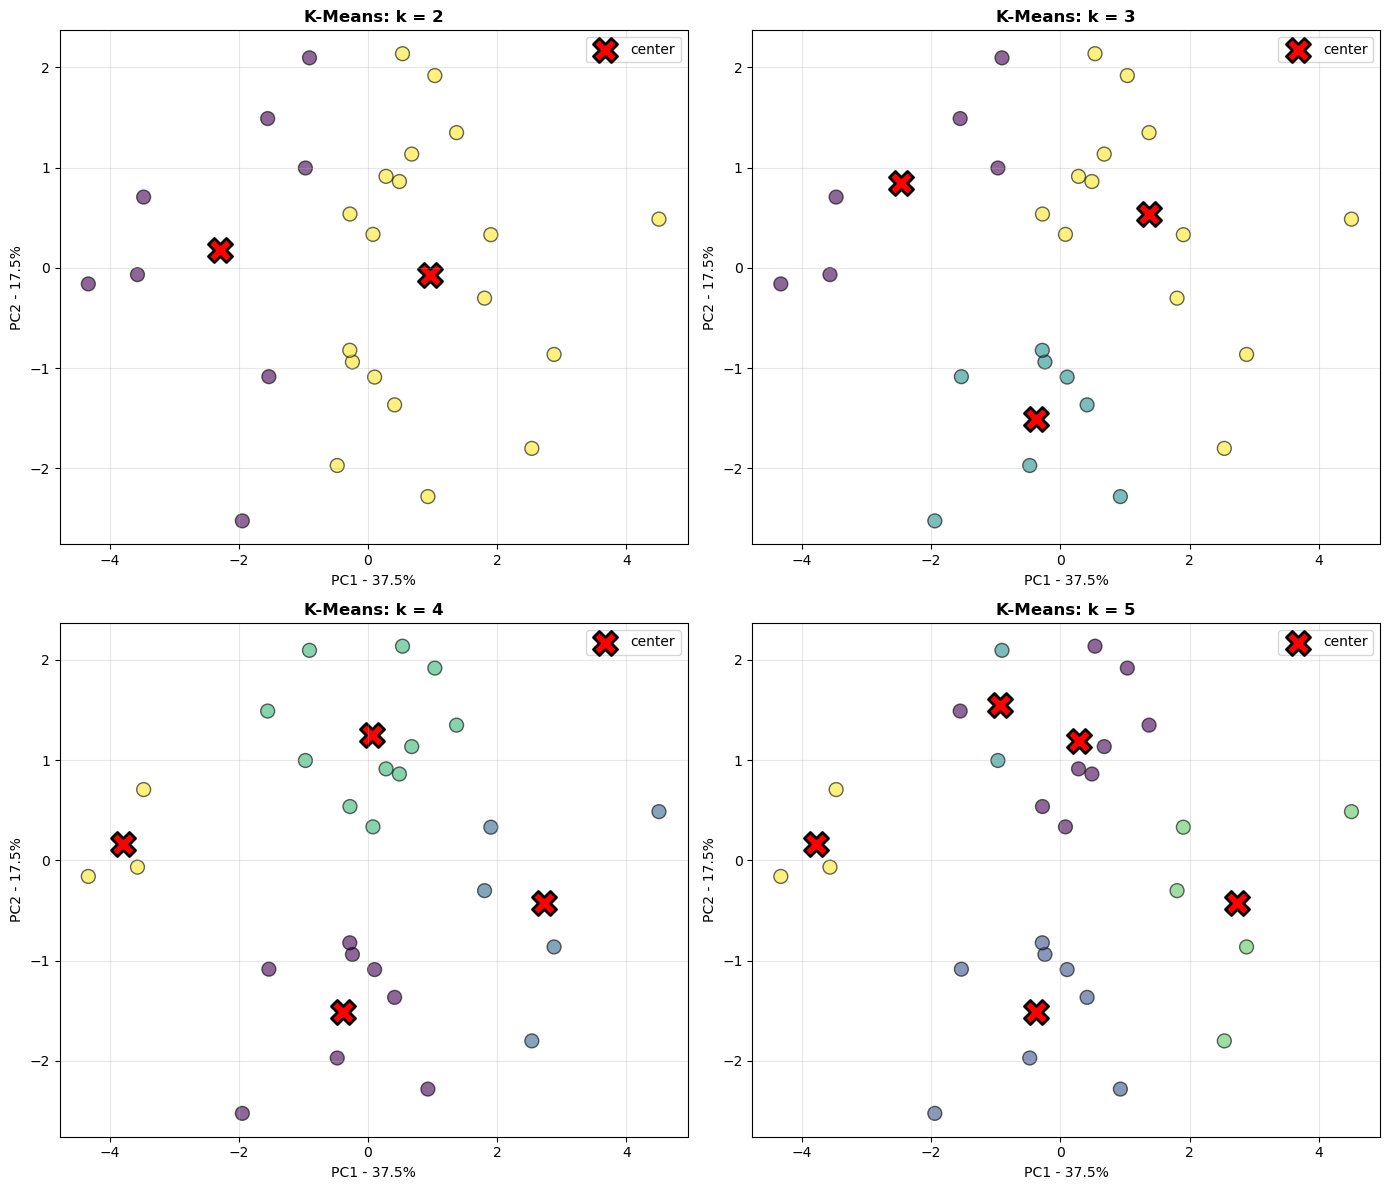

In [5]:
from sklearn.cluster import KMeans

# 复用已存在的变量
X_scaled = scaled_data
X_pca = pca_result
explained_variance = pca_var_per

# 使用sklearn的KMeans进行聚类并可视化
K_values = [2, 3, 4, 5]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, k in enumerate(K_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    axes[idx].scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=clusters, cmap='viridis',
        alpha=0.6, edgecolors='k', s=100
    )
    
    centers_pca = pca.transform(kmeans.cluster_centers_) # 将中心点从原始空间转换到PCA空间
    axes[idx].scatter(
        centers_pca[:, 0], centers_pca[:, 1],
        c='red', marker='X', s=300,
        edgecolors='black', linewidths=2, label='center'
    )
    
    axes[idx].set_xlabel(f'PC1 - {explained_variance[0]:.1f}%', fontsize=10)
    axes[idx].set_ylabel(f'PC2 - {explained_variance[1]:.1f}%', fontsize=10)
    axes[idx].set_title(f'K-Means: k = {k}', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

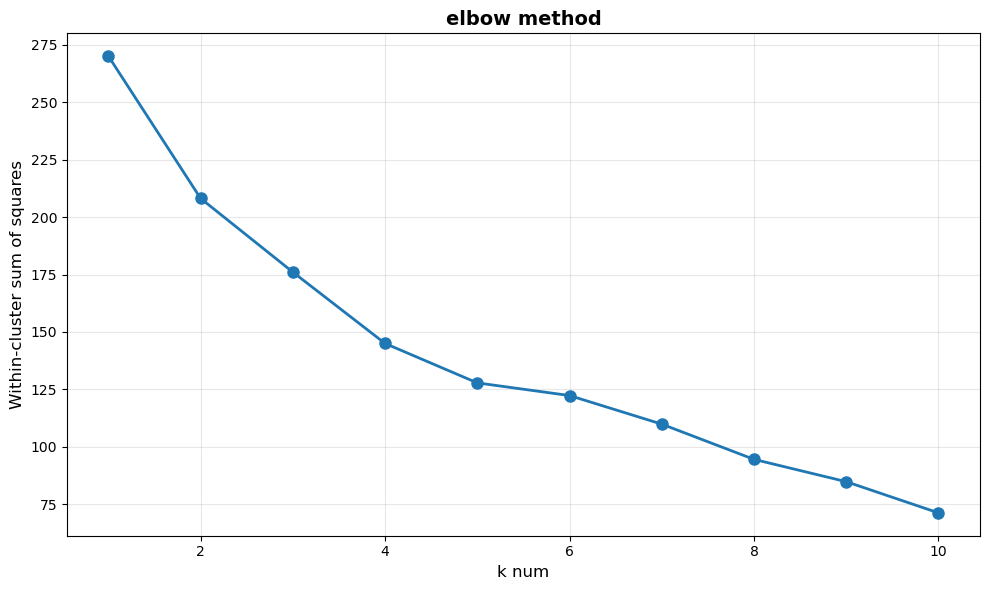

观察图中的'肘部'来确定最佳K值


In [ ]:
# 肘部法则 (Elbow Method) - 确定最佳K值
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) 
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, marker='o', linewidth=2, markersize=8)
plt.xlabel('k num', fontsize=12)
plt.ylabel('Within-cluster sum of squares', fontsize=12)
plt.title('elbow method', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("观察图中的'肘部'来确定最佳K值")

## 层次聚类 (Hierarchical Clustering)

### 什么是层次聚类?

- K-Means聚类的替代方法，用于识别数据集中的组
- 不需要预先指定聚类数量
- 生成基于树的观察表示，称为树状图 (dendrogram)

### 链接方法:

- **Complete linkage**: 簇间最大距离
- **Single linkage**: 簇间最小距离
- **Average linkage**: 簇间平均距离
- **Ward linkage**: 最小化簇内方差

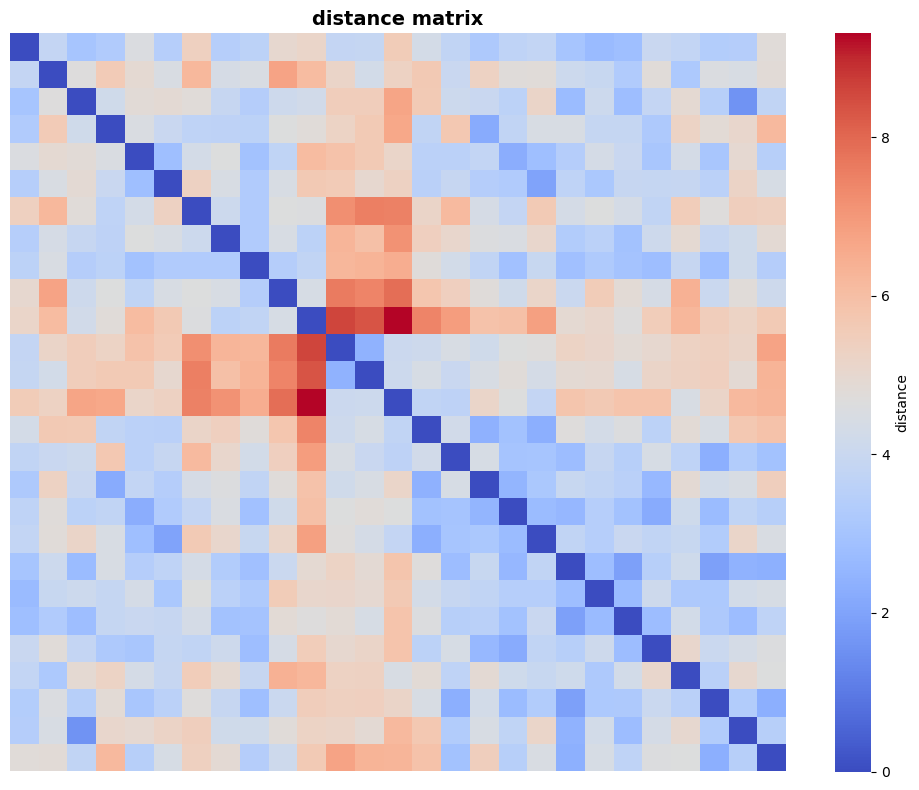

In [10]:
# 计算距离矩阵
from scipy.spatial.distance import pdist, squareform

# 使用欧氏距离
distances = pdist(X_scaled, metric='euclidean')
distance_matrix = squareform(distances)

# 可视化距离矩阵
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, cmap='coolwarm', 
            xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'distance'})
plt.title('distance matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/gl/9b_dtvz53kx64dg__hpx5qyr0000gn/T/ipykernel_11722/2657793319.py:15: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gl/9b_dtvz53kx64dg__hpx5qyr0000gn/T/ipykernel_11722/2657793319.py:15: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gl/9b_dtvz53kx64dg__hpx5qyr0000gn/T/ipykernel_11722/2657793319.py:15: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gl/9b_dtvz53kx64dg__hpx5qyr0000gn/T/ipykernel_11722/2657793319.py:15: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gl/9b_dtvz53kx64dg__hpx5qyr0000gn/T/ipykernel_11722/2657793319.py:15: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gl/9b_d

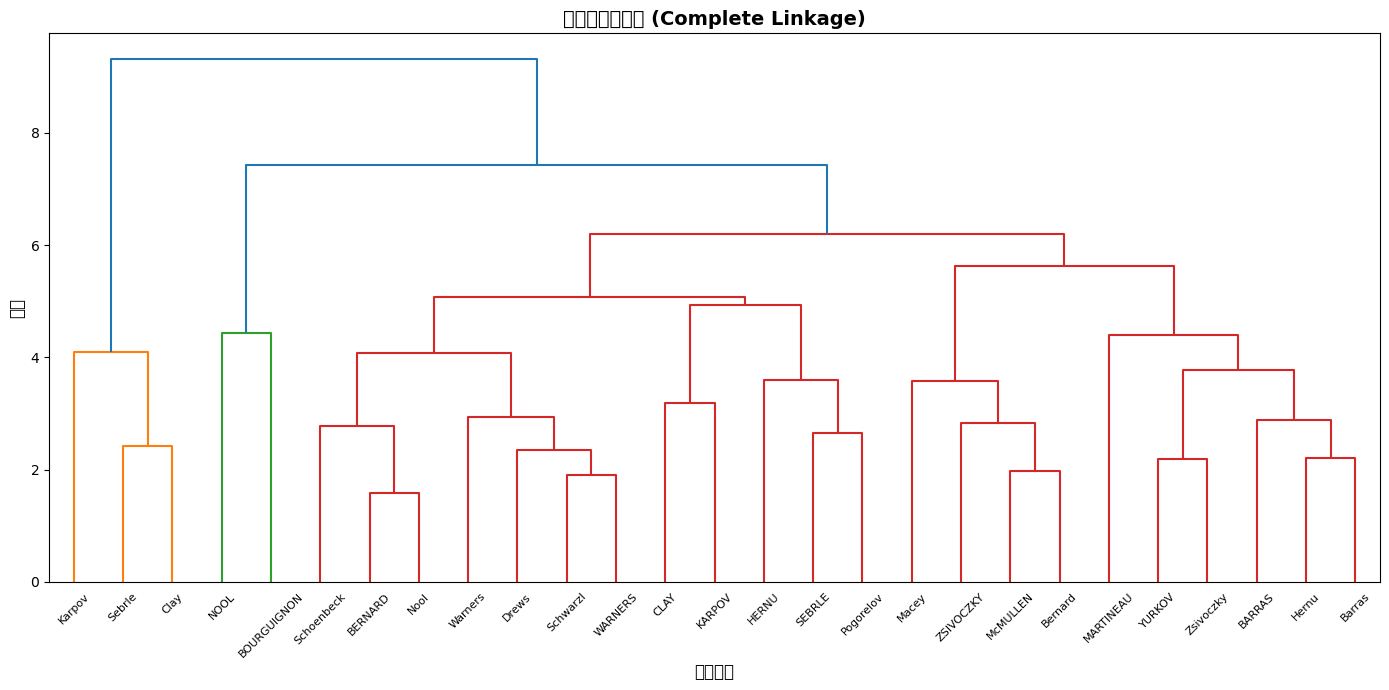

In [ ]:
# 执行层次聚类
from scipy.cluster.hierarchy import dendrogram, linkage

# 使用complete linkage
linkage_matrix = linkage(X_scaled, method='complete', metric='euclidean')

# 绘制树状图
plt.figure(figsize=(14, 7))
dendrogram(linkage_matrix, 
           labels=decathlon2_active.index.tolist(),
           leaf_font_size=8)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.title('H-Clustering Dendrogram (Complete Linkage)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 批次效应 (Batch Effect)

### 为什么批次效应是一个问题?

- 技术变异可能掩盖生物信号
- 不同批次的样本可能表现出系统性差异
- 需要在下游分析之前进行校正

### 批次效应去除方法:

在Python中，可以使用以下方法:
- **Combat** (通过rpy2调用R的sva包)
- **Harmony** (scanpy.external.pp.harmony_integrate)
- **其他方法**: 如线性模型回归等

注意: 实际的批次效应去除通常需要使用专门的包，这里展示概念。

In [ ]:
# 模拟批次效应示例
np.random.seed(42)

# 创建模拟数据：两个批次
n_samples_per_batch = 50
n_features = 100

# 批次1
batch1 = np.random.randn(n_samples_per_batch, n_features)
# 批次2 - 添加系统性偏移（批次效应）
batch2 = np.random.randn(n_samples_per_batch, n_features) + 2

# 合并数据
data_with_batch = np.vstack([batch1, batch2])
batch_labels = np.array(['Batch1'] * n_samples_per_batch + ['Batch2'] * n_samples_per_batch)

# PCA可视化批次效应
pca_batch = PCA(n_components=2)
data_pca = pca_batch.fit_transform(data_with_batch)

plt.figure(figsize=(12, 5))

# 批次效应前
plt.subplot(1, 2, 1)
for batch in ['Batch1', 'Batch2']:
    mask = batch_labels == batch
    plt.scatter(data_pca[mask, 0], data_pca[mask, 1], 
               label=batch, alpha=0.6, s=50)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('批次效应去除前', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 简单的批次效应去除：中心化每个批次
data_corrected = data_with_batch.copy()
for batch in ['Batch1', 'Batch2']:
    mask = batch_labels == batch
    data_corrected[mask] = data_with_batch[mask] - data_with_batch[mask].mean(axis=0)

data_corrected_pca = pca_batch.fit_transform(data_corrected)

# 批次效应后
plt.subplot(1, 2, 2)
for batch in ['Batch1', 'Batch2']:
    mask = batch_labels == batch
    plt.scatter(data_corrected_pca[mask, 0], data_corrected_pca[mask, 1], 
               label=batch, alpha=0.6, s=50)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('批次效应去除后（简单中心化）', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("注意：实际分析中应使用Combat或其他专业方法进行批次效应校正")

## DESeq2差异表达分析

### 什么是DESeq2?

- RNA-seq数据的差异表达分析工具
- 基于负二项分布模型
- 可以处理小样本量

### Python替代方案:

1. **PyDESeq2**: Python实现的DESeq2
2. **rpy2**: 调用R的DESeq2包
3. **limma-voom**: 通过rpy2调用

这里我们展示概念性的差异表达分析。

## GSEA (基因集富集分析)

### DAVID vs. GSEA

- **DAVID**: 获取选定的差异表达基因列表，查看某些基因集中的基因是否通过计数过度代表
- **GSEA**: 获取所有基因并使用测试统计量（例如t值）。不需要设置阈值

### GSEA分析步骤:

1. 对所有基因进行排序
2. 识别基因集中所有成员在排序数据集中的秩位置
3. 计算富集分数(ES)，表示观察到的排名与假设随机排名分布之间的差异

### Python中的GSEA:

- **gseapy**: Python的GSEA实现
- 可以使用MSigDB数据库
- 支持预排序GSEA分析